In [1]:
#models
library(tidyverse)
library(caret)
library(recipes)
library(pROC)
library(dplyr)
library(tidyr)
library(ppcor)
options(jupyter.rich_display = FALSE)


── Attaching core tidyverse packages ────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ──────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: lattice


Attaching package: ‘caret’


The following object is masked from ‘package:purrr’:

    lift



Attaching package: ‘recipes’


The following object is masked from ‘package:stringr’:

    fixed


The following object is masked from ‘package:stats’:

    step


Type 'citation("pROC")' for a citation.


Attaching packa

In [2]:
mica_df <- read_csv("../../data/mica_df_with_pcs.csv")
lucas_df <- read_csv("../../data/lucas_df_with_pcs.csv")
val_df <- read_csv("../../data/val_df_with_pcs.csv") # JHU Cohort

mica_df <- mica_df %>%
  mutate(olink_CEA = log2(clinical_CEA + 1))

lucas_df <- lucas_df %>%
  mutate(olink_CEA = log2(clinical_CEA + 1))

Rows: 540 Columns: 1304
── Column specification ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr   (73): id, Stage, Coded Type, type, Delfi ID (Aliquot 2), DL ID, DL Suf...
dbl (1225): clinical_CCI, clinical_age, Smoking, ratio_1, ratio_2, ratio_3, ...
lgl    (6): Match?, Rack (plasma), Rack (cfDNA), check, Robot Protocol, Repl...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 287 Columns: 958
── Column specification ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr   (96): Patient, id, type, clinical_smokingstatus, QC, patient.type, cli...
dbl  (850): multinucratio, clinical_nlratio, clinical_CRP, clinical_cfdna_co...
lgl    (3): DIAGNOSE_OTHER_PRIMARY, Adaptor Dimer, Date Data Received
date   (9): 

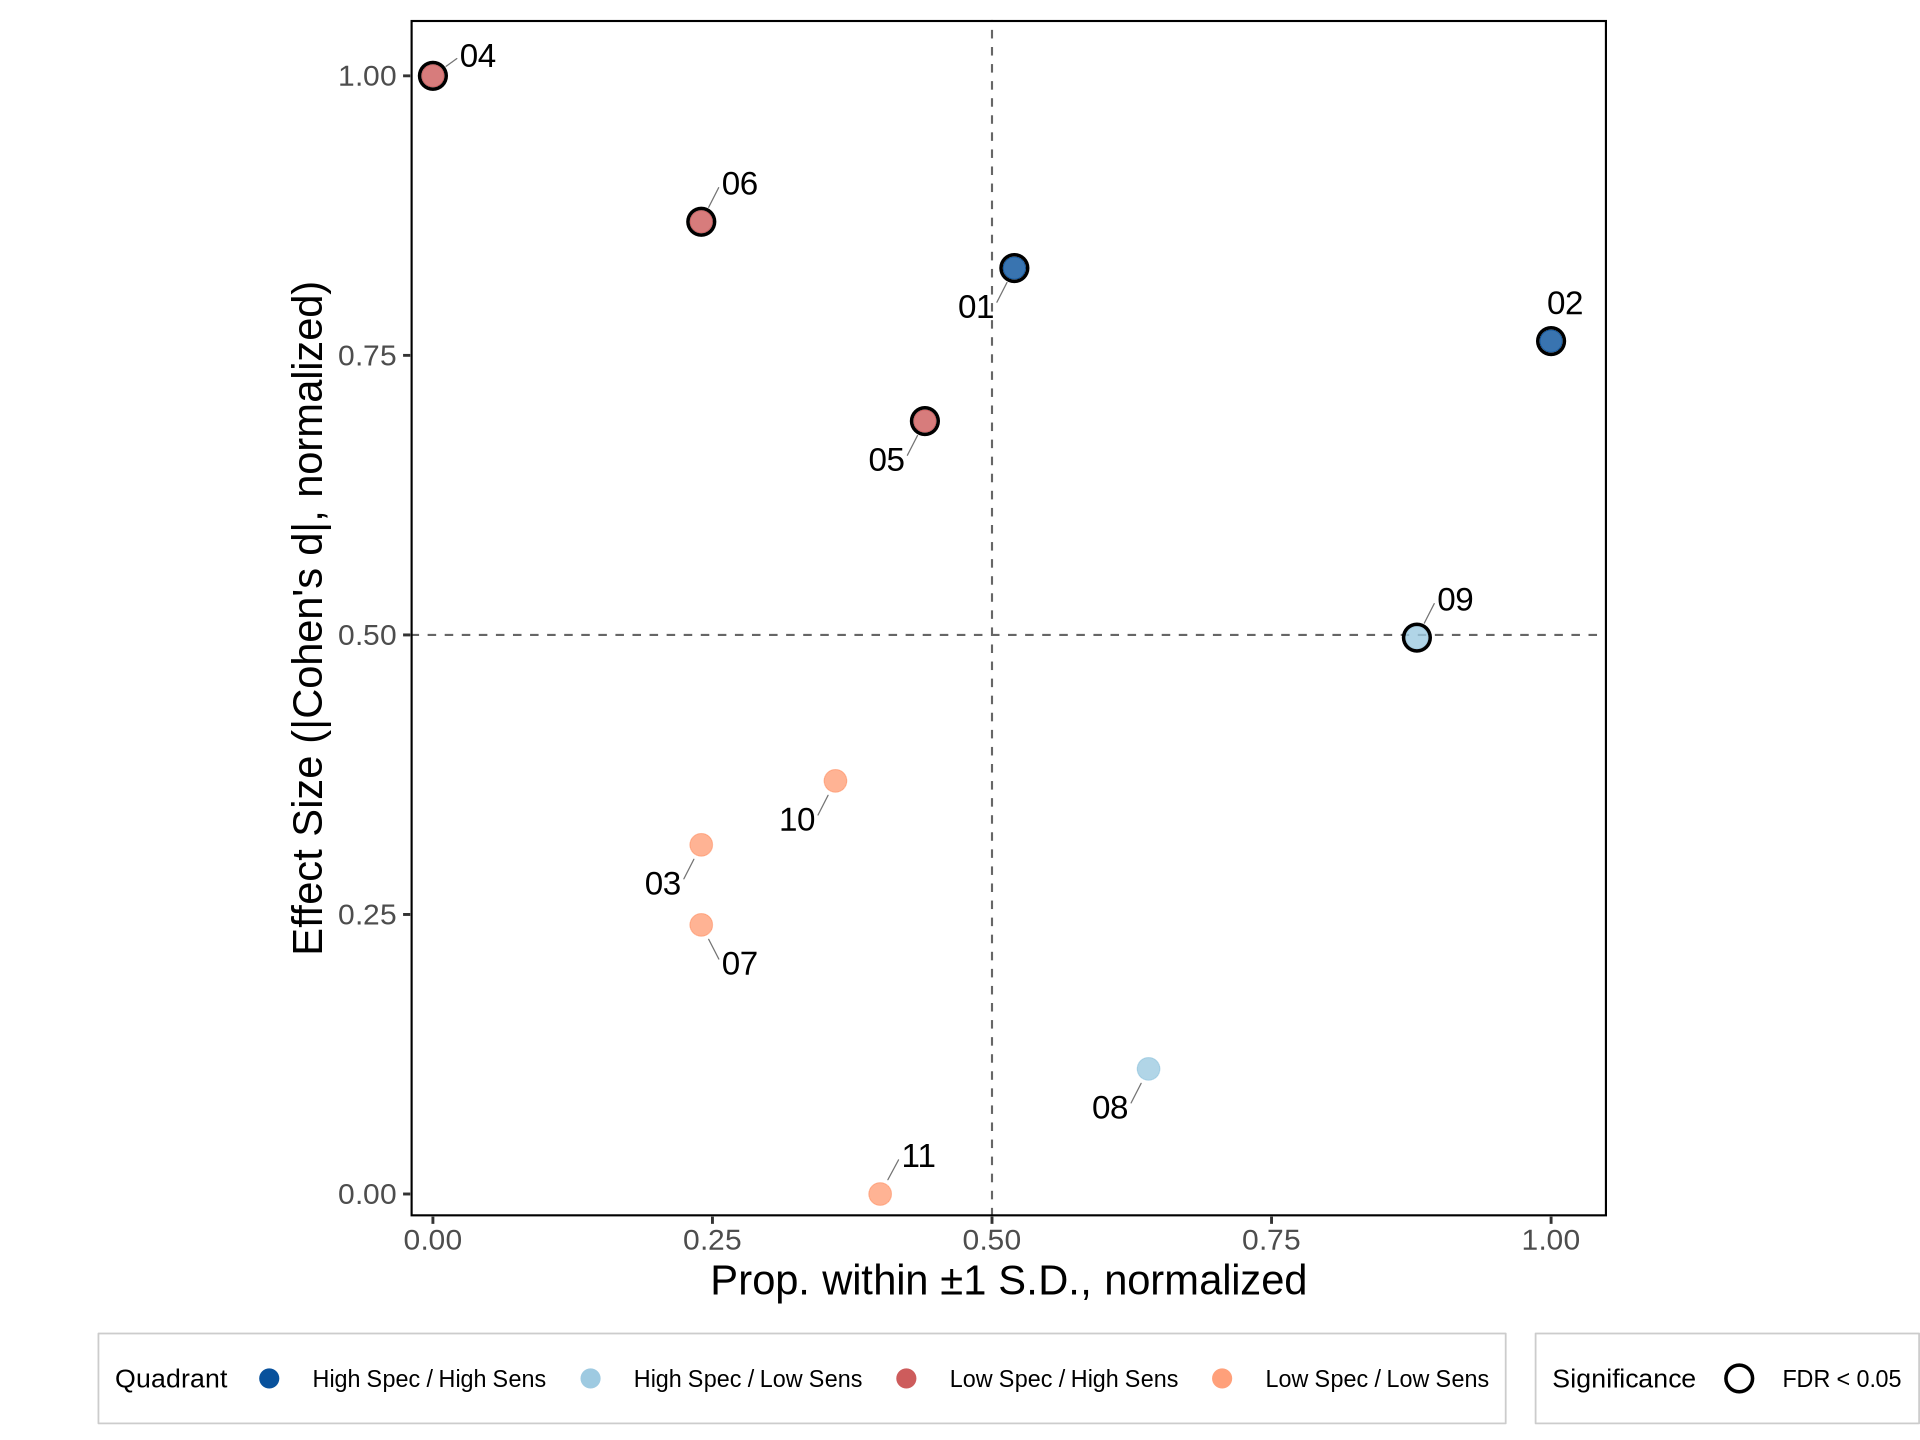

In [3]:
library(tidyverse)
library(ggrepel)

# =============================================================================
# BIOMARKER PERFORMANCE QUADRANT - Publication Style
# =============================================================================

# ---- Setup: Calculate metrics ----
ratio_pc_cols <- colnames(val_df)[str_starts(colnames(val_df), "ratio_pc_")]

# Add zscore_2p as benchmark
feature_cols <- c(ratio_pc_cols)
feature_cols <- feature_cols[feature_cols %in% colnames(val_df)]

# Calculate separation metrics
quadrant_df <- map_dfr(feature_cols, function(col) {
  
  healthy_vals <- val_df %>% filter(type == "healthy") %>% pull(!!sym(col))
  cancer_vals <- val_df %>% filter(type == "cancer") %>% pull(!!sym(col))
  
  healthy_vals <- healthy_vals[!is.na(healthy_vals)]
  cancer_vals <- cancer_vals[!is.na(cancer_vals)]
  
  # Cohen's d (sensitivity)
  pooled_sd <- sqrt((sd(healthy_vals)^2 + sd(cancer_vals)^2) / 2)
  d <- (mean(cancer_vals) - mean(healthy_vals)) / pooled_sd
  
  # ---- Alternative Specificity Metrics ----
  
  # 1. Original: inverse SD
  healthy_sd <- sd(healthy_vals)
  spec_inv_sd <- 1 / healthy_sd
  
  # 2. Proportion within ±1 SD of median (tighter = more specific)
  healthy_median <- median(healthy_vals)
  healthy_mad <- mad(healthy_vals, constant = 1.4826)  # scaled MAD

  prop_within_1sd <- mean(abs(healthy_vals - healthy_median) <= healthy_mad)
  
  # 3. Inverse IQR (robust to outliers)
  healthy_iqr <- IQR(healthy_vals)
  spec_inv_iqr <- 1 / healthy_iqr
  
  # 4. Inverse MAD (median absolute deviation - robust)
  spec_inv_mad <- 1 / healthy_mad
  
  # 5. False positive rate proxy: % of healthy samples exceeding cancer median
  cancer_median <- median(cancer_vals)
  if (d > 0) {
    fpr_proxy <- mean(healthy_vals >= cancer_median)
  } else {
    fpr_proxy <- mean(healthy_vals <= cancer_median)
  }
  spec_fpr <- 1 - fpr_proxy
  
  # 6. Signal-to-noise in healthy
  snr_healthy <- abs(mean(healthy_vals)) / sd(healthy_vals)
  spec_snr <- 1 / (1 + snr_healthy)
  
  # Wilcoxon test for significance
  tt <- wilcox.test(cancer_vals, healthy_vals)
  
  tibble(
    feature = col,
    feature_clean = case_when(
      col == "zscore_2p" ~ "Zscore 2p \n",
      TRUE ~ str_remove(col, "^ratio_pc_")
    ),
    cohens_d = d,
    abs_cohens_d = abs(d),
    healthy_sd = healthy_sd,
    healthy_iqr = healthy_iqr,
    healthy_mad = healthy_mad,
    spec_inv_sd = spec_inv_sd,
    spec_inv_iqr = spec_inv_iqr,
    spec_inv_mad = spec_inv_mad,
    spec_fpr = spec_fpr,
    spec_within_1sd = prop_within_1sd,
    p_value = tt$p.value,
    mean_healthy = mean(healthy_vals),
    mean_cancer = mean(cancer_vals)
  )
}) %>%
  mutate(
    p_adj = p.adjust(p_value, method = "BH"),
    
    # Use proportion within ±1 MAD as specificity
    specificity = spec_within_1sd, ##################################################################
    
    # Normalize to 0-1 scale
    sensitivity_norm = (abs_cohens_d - min(abs_cohens_d)) / (max(abs_cohens_d) - min(abs_cohens_d)),
    specificity_norm = (specificity - min(specificity)) / (max(specificity) - min(specificity)),
    
    # Significance flag
    sig_flag = p_adj < 0.05,
    
    # Benchmark flag
    is_benchmark = feature == "zscore_2p",
    
    # Quadrant-based coloring (High Spec = blue, Low Spec = red)
    grp = case_when(
      is_benchmark ~ "Benchmark",
      specificity_norm >= 0.5 & sensitivity_norm >= 0.5 ~ "High Spec / High Sens",
      specificity_norm >= 0.5 & sensitivity_norm < 0.5 ~ "High Spec / Low Sens",
      specificity_norm < 0.5 & sensitivity_norm >= 0.5 ~ "Low Spec / High Sens",
      TRUE ~ "Low Spec / Low Sens"
    ),
    grp = factor(grp, levels = c(
      "High Spec / High Sens",
      "High Spec / Low Sens",
      "Low Spec / High Sens",
      "Low Spec / Low Sens",
      "Benchmark"
    )),
    # Significance factor for legend
    sig_label = ifelse(sig_flag, "FDR < 0.05", "FDR ≥ 0.05")
  )

# Color palette: Blue hues for high specificity, Red hues for low specificity
quadrant_pal <- c(
  "High Spec / High Sens" = "#08519C",
  "High Spec / Low Sens" = "#9ECAE1",
  "Low Spec / High Sens" = "#CD5C5C",
  "Low Spec / Low Sens" = "#FFA07A",
  "Benchmark" = "#2CA02C"
)

# ---- Publication-style Quadrant Plot ----
p_quadrant <- ggplot(quadrant_df, aes(x = specificity_norm, y = sensitivity_norm)) +
  # Quadrant lines
  geom_vline(xintercept = 0.5, linetype = "dashed", color = "gray40", linewidth = 0.6) +
  geom_hline(yintercept = 0.5, linetype = "dashed", color = "gray40", linewidth = 0.6) +
  # Base points (color by quadrant)
  geom_point(aes(color = grp), size = 6, alpha = 0.8) +
  # Black ring around significant points (mapped to shape legend)
  geom_point(
    data = dplyr::filter(quadrant_df, sig_flag),
    aes(x = specificity_norm, y = sensitivity_norm, shape = "FDR < 0.05"),
    fill = NA, color = "black", stroke = 1.5, size = 6.5
  ) +
  # Labels
  geom_text_repel(
    aes(label = feature_clean),
    size = 7,
    box.padding = 1.0,
    point.padding = 1.2,
    max.overlaps = Inf,
    segment.color = "gray45",
    segment.size = 0.35
  ) +
  # Color scale with legend
  scale_color_manual(
    values = quadrant_pal,
    name = "Quadrant"
  ) +
  # Shape scale for significance ring
  scale_shape_manual(
    values = c("FDR < 0.05" = 21),
    name = "Significance"
  ) +
  # Axis settings
  scale_x_continuous(
    limits = c(0, 1),
    breaks = seq(0, 1, 0.25),
    expand = expansion(mult = c(0.02, 0.05))
  ) +
  scale_y_continuous(
    limits = c(0, 1),
    breaks = seq(0, 1, 0.25),
    expand = expansion(mult = c(0.02, 0.05))
  ) +
  # Labels
  labs(
    x = "Prop. within ±1 S.D., normalized",
    y = "Effect Size (|Cohen's d|, normalized)"
  ) +
  # Theme matching volcano plot
  theme_bw(base_size = 18) +
  theme(
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    panel.border = element_rect(color = "black", fill = NA, linewidth = 1.2),
    legend.position = "bottom",
    legend.title = element_text(size = 16),
    legend.text = element_text(size = 14),
    legend.key.size = unit(1.2, "cm"),
    legend.background = element_rect(fill = "white", color = "gray80", linewidth = 0.5),
    legend.margin = margin(10, 10, 10, 10),
    legend.spacing.y = unit(0.5, "cm"),
    axis.text = element_text(size = 18),
    axis.title = element_text(size = 25),
    plot.background = element_rect(fill = "white", color = NA),
    plot.margin = margin(12, 22, 10, 10)
  ) +
  coord_fixed(ratio = 1) +
  guides(
    color = guide_legend(
      order = 1,
      override.aes = list(size = 5, alpha = 1)
    ),
    shape = guide_legend(
      order = 2,
      override.aes = list(size = 6.5, stroke = 1.5, fill = NA, color = "black")
    )
  )

# ---- Display ----
options(repr.plot.width = 16, repr.plot.height = 12)
print(p_quadrant)

In [4]:
ggsave(
    filename = "../../outputs/Fig5/Fig-Frag-Spec.png",
    plot = p_quadrant,
    width = 18,
    height = 12,
    dpi = 600,
     units = "in",
    bg = "white",
    create.dir = TRUE
)

In [ ]:
# Done #